# SWRC comparison (same soil): Brooks–Corey vs van Genuchten vs Kosugi

> Add blockquote


This notebook draws **three typical soil water retention curves (SWRC)** for the **same soil** (same $\\theta_r$ and $\\theta_s$),
using three common models:

1. **Brooks–Corey**
2. **van Genuchten** (with effective saturation)
3. **Kosugi** (lognormal capillary-pressure distribution)

Finally it plots **all three curves together**.

Curves are plotted as $\\theta(\\psi)$ vs suction $|\\psi|$ in **kPa** on a **log x-axis** (common in soil physics).
Switch to a linear x-axis by commenting out `ax.set_xscale('log')` in the plotting cells.

---
## Structure of this notebook

| Section | Content |
|---------|---------|
| 1 | Imports and shared setup |
| 2 | Typical parameter tables per soil texture |
| 3 | Set parameters for the run |
| 4–7 | Individual and combined plots |
| 8 | Optional export |


## 1) Imports and shared setup

All functions are defined here and all packages are being imported. In this way, the rest of the notebook is purely parameter-setting and plotting.


In [1]:
# SETUP CELL — run once
try:
    from soil_course import *
except:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *
psi = make_psi()

print("Setup complete")

  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-kk90lie4
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-kk90lie4
  Resolved https://github.com/panzerotto/soil_course.git to commit de51301b8e0fa6c0fb6cc77aa6324b226b726c98
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=3623 sha256=0424f6b3b39b72b13313ce8ebf7741cfad969c4f32e99e416140e37b736c1361
  Stored in directory: /tmp/pip-ephem-wheel-cache-ityemd8t/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


## 2) Typical parameters per soil texture

The tables below give literature-representative values for several common USDA texture classes.
Use them to choose a starting point; values vary with measurement method and source.

### 2a) Shared water-content parameters

| Texture          | θ_r   | θ_s   | Reference |
|------------------|-------|-------|-----------|
| Sand             | 0.045 | 0.43  | Carsel & Parrish (1988) |
| Loamy sand       | 0.057 | 0.41  | Carsel & Parrish (1988) |
| Sandy loam       | 0.065 | 0.41  | Carsel & Parrish (1988) |
| Loam             | 0.078 | 0.43  | Carsel & Parrish (1988) |
| Silt loam        | 0.067 | 0.45  | Carsel & Parrish (1988) |
| Sandy clay loam  | 0.100 | 0.39  | Carsel & Parrish (1988) |
| Clay loam        | 0.095 | 0.41  | Carsel & Parrish (1988) |
| Silty clay loam  | 0.089 | 0.43  | Carsel & Parrish (1988) |
| Sandy clay       | 0.100 | 0.38  | Carsel & Parrish (1988) |
| Silty clay       | 0.070 | 0.36  | Carsel & Parrish (1988) |
| Clay             | 0.068 | 0.38  | Carsel & Parrish (1988) |


### 2b) Brooks–Corey parameters

| Texture          | ψ_b (kPa) | λ     | Reference |
|------------------|-----------|-------|-----------|
| Sand             |  0.73     | 0.592 | Rawls et al. (1982) |
| Loamy sand       |  0.87     | 0.474 | Rawls et al. (1982) |
| Sandy loam       |  1.47     | 0.322 | Rawls et al. (1982) |
| Loam             |  1.11     | 0.220 | Rawls et al. (1982) |
| Silt loam        |  2.08     | 0.211 | Rawls et al. (1982) |
| Sandy clay loam  |  2.89     | 0.250 | Rawls et al. (1982) |
| Clay loam        |  2.59     | 0.194 | Rawls et al. (1982) |
| Silty clay loam  |  3.26     | 0.151 | Rawls et al. (1982) |
| Sandy clay       |  2.91     | 0.168 | Rawls et al. (1982) |
| Silty clay       |  3.41     | 0.127 | Rawls et al. (1982) |
| Clay             |  3.73     | 0.131 | Rawls et al. (1982) |

> **Note** ψ_b is the air-entry (bubbling) pressure; λ is the Brooks–Corey pore-size distribution index.


### 2c) van Genuchten parameters (Mualem, m = 1 − 1/n)

| Texture          | α (1/kPa) | n     | Reference |
|------------------|-----------|-------|-----------|
| Sand             | 0.145     | 2.68  | Carsel & Parrish (1988) |
| Loamy sand       | 0.124     | 2.28  | Carsel & Parrish (1988) |
| Sandy loam       | 0.075     | 1.89  | Carsel & Parrish (1988) |
| Loam             | 0.036     | 1.56  | Carsel & Parrish (1988) |
| Silt loam        | 0.020     | 1.41  | Carsel & Parrish (1988) |
| Sandy clay loam  | 0.059     | 1.48  | Carsel & Parrish (1988) |
| Clay loam        | 0.019     | 1.31  | Carsel & Parrish (1988) |
| Silty clay loam  | 0.010     | 1.23  | Carsel & Parrish (1988) |
| Sandy clay       | 0.027     | 1.23  | Carsel & Parrish (1988) |
| Silty clay       | 0.005     | 1.09  | Carsel & Parrish (1988) |
| Clay             | 0.008     | 1.09  | Carsel & Parrish (1988) |

> **Note** α ≈ 1/ψ_b; n controls the width of the transition zone.


### 2d) Kosugi parameters

| Texture          | ψ_m (kPa) | σ     | Reference |
|------------------|-----------|-------|-----------|
| Sand             |  1.5      | 0.50  | Kosugi (1996); Leij et al. (1999) |
| Loamy sand       |  2.5      | 0.55  | Leij et al. (1999) |
| Sandy loam       |  6.0      | 0.65  | Kosugi (1996) |
| Loam             | 10.0      | 0.70  | Kosugi (1996) |
| Silt loam        | 20.0      | 0.80  | Kosugi (1996) |
| Sandy clay loam  | 15.0      | 0.75  | Leij et al. (1999) |
| Clay loam        | 30.0      | 0.85  | Leij et al. (1999) |
| Silty clay loam  | 50.0      | 0.90  | Leij et al. (1999) |
| Sandy clay       | 25.0      | 0.80  | Leij et al. (1999) |
| Silty clay       | 70.0      | 0.95  | Leij et al. (1999) |
| Clay             |100.0      | 1.00  | Leij et al. (1999) |

> **Note** ψ_m is the median suction (modal pore radius); σ is the standard deviation of ln(ψ) and controls the spread of the pore-size distribution.


## 3) Set parameters for this run

Edit the values below to match your soil (or copy from the tables above).


In [2]:
# ── Shared water-content parameters ──────────────────────────────────────────
theta_r = 0.05    # residual water content  [-]
theta_s = 0.45    # saturated water content [-]

# ── Brooks–Corey ─────────────────────────────────────────────────────────────
psi_b = 10.0      # air-entry suction ψ_b   [kPa]
lam   = 0.60      # pore-size index λ        [-]

# ── van Genuchten ─────────────────────────────────────────────────────────────
alpha = 0.05      # α                        [1/kPa]
n_vg  = 1.60      # n                        [-]

# ── Kosugi ────────────────────────────────────────────────────────────────────
psi_m   = 20.0    # median suction ψ_m       [kPa]
sigma_k = 1.00    # σ                        [-]

# ── Compute curves ────────────────────────────────────────────────────────────
Se_BC = Se_brooks_corey(psi,    psi_b_kpa=psi_b, lam=lam)
Se_VG = Se_van_genuchten(psi,   alpha_kpa_inv=alpha, n=n_vg)
Se_K  = Se_kosugi(psi,          psi_m_kpa=psi_m, sigma=sigma_k)

theta_BC = theta_from_Se(Se_BC, theta_r, theta_s)
theta_VG = theta_from_Se(Se_VG, theta_r, theta_s)
theta_K  = theta_from_Se(Se_K,  theta_r, theta_s)

## 4) Plot 1 — Brooks–Corey SWRC

---

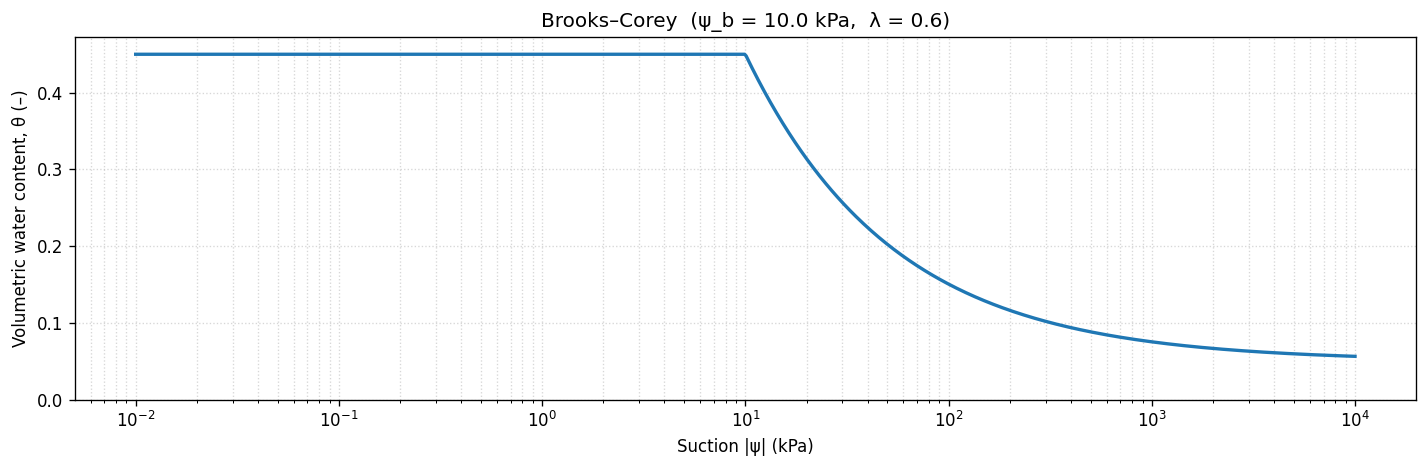

In [3]:
plot_brooks_corey(psi, theta_BC, theta_s, psi_b, lam)

## 5) Plot 2 — van Genuchten SWRC

---

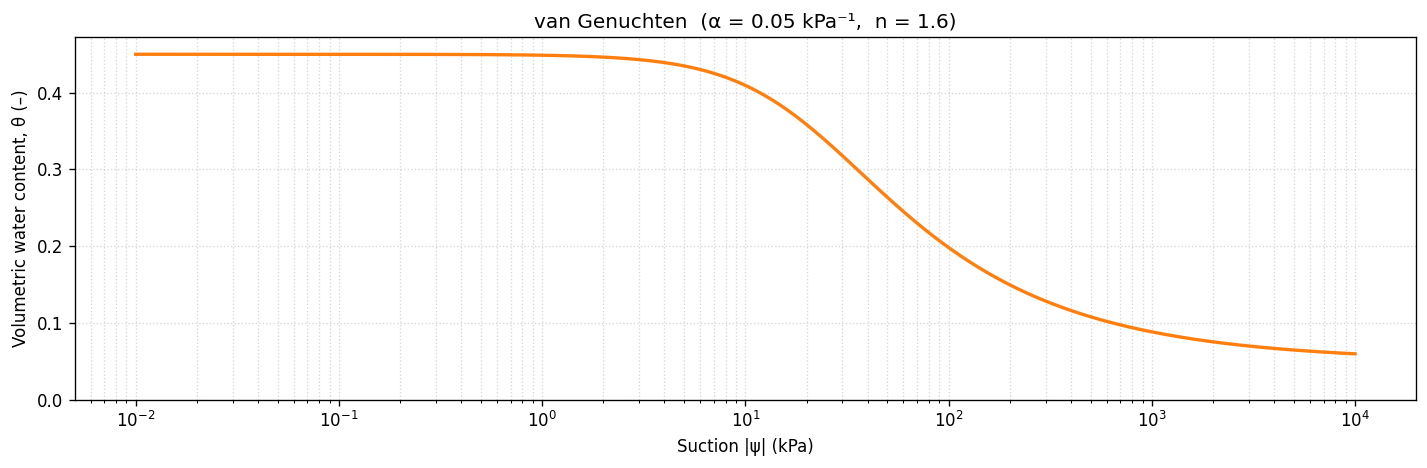

In [4]:
plot_van_genuchten(psi, theta_VG, theta_s, alpha, n_vg)

## 6) Plot 3 — Kosugi SWRC
---

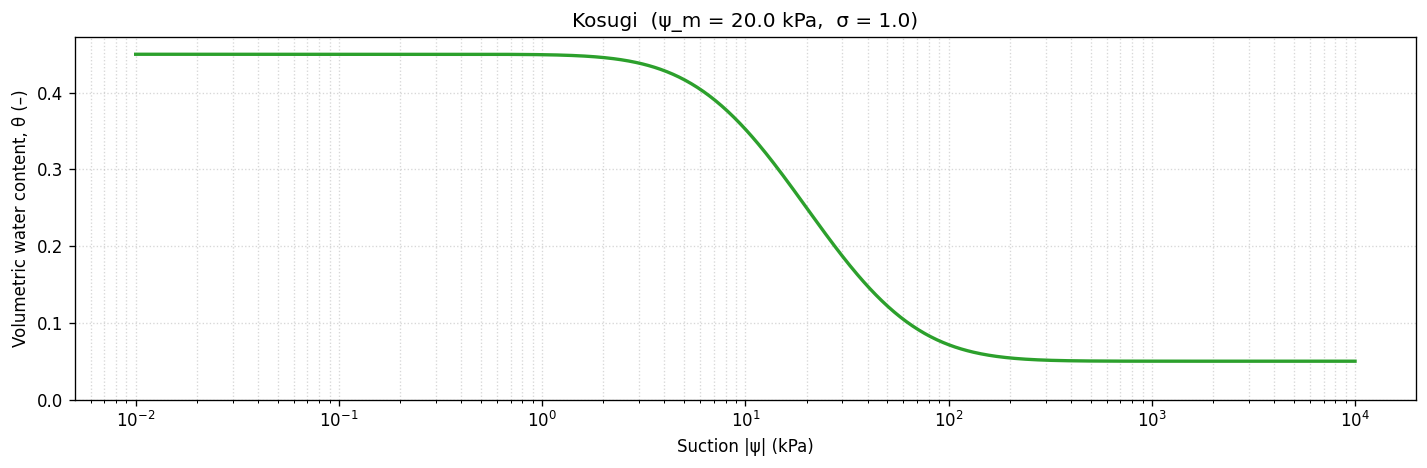

In [5]:
plot_kosugi(psi, theta_K, theta_s, psi_m, sigma_k)

## 7) Plot 4 — All three curves together

---

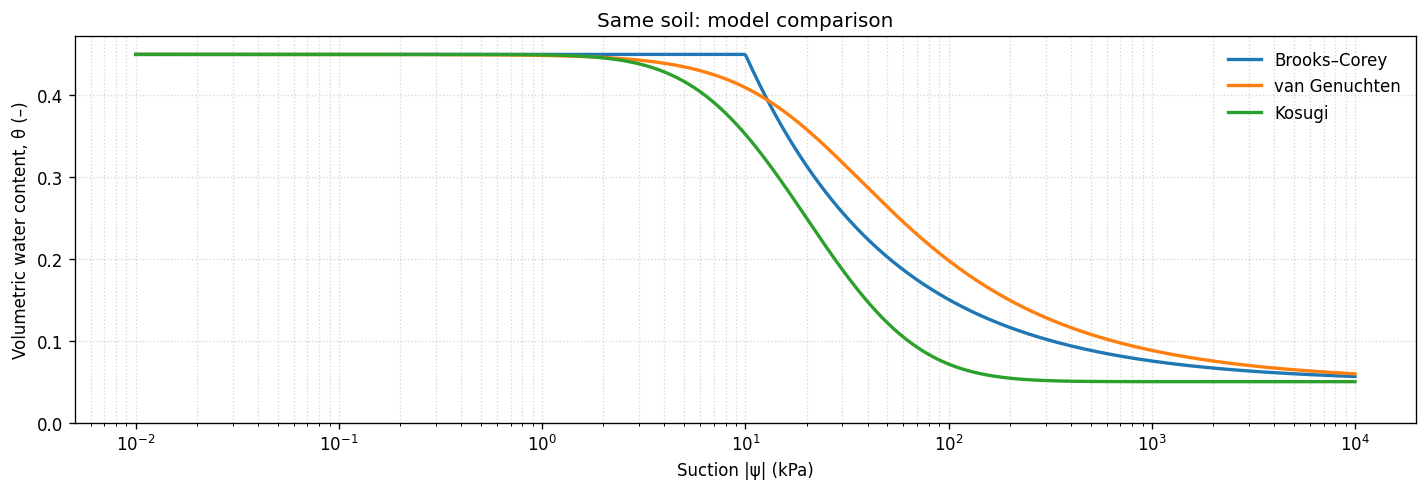

In [6]:
plot_all_swrc(psi, theta_BC, theta_VG, theta_K, theta_s)

## 8) Optional export for slides

---

In [7]:
# fig1.savefig('swrc_brooks_corey.png',  dpi=300, bbox_inches='tight')
# fig2.savefig('swrc_van_genuchten.png', dpi=300, bbox_inches='tight')
# fig3.savefig('swrc_kosugi.png',        dpi=300, bbox_inches='tight')
# fig4.savefig('swrc_all_three.png',     dpi=300, bbox_inches='tight')
# print('Saved PNGs')